# 04 — Mô hình truy xuất tài liệu

**Hạng mục 3: mô hình truy xuất tài liệu.**

Câu hỏi của notebook này: trong các mô hình truy xuất kinh điển, mô hình nào
phù hợp với bộ dữ liệu RETECO Track 1a?

Notebook **không** chọn trước một mô hình rồi đi tìm lý do biện minh. Cả năm
mô hình được đo trên cùng dữ liệu, cùng cách tách từ, cùng cách chấm điểm. Mô
hình nào thắng thì thắng.

### Vì sao phải đo

Notebook `03a` đã cho một bài học cụ thể: ba giả thuyết nghe rất hợp lý đều bị
số liệu bác bỏ, trong đó có một trường hợp **đảo dấu** — cùng một thay đổi, với
bộ tách từ này thì tốt lên, với bộ tách từ khác thì xấu đi.

Nên ở đây mỗi mô hình được chạy với **hai bộ tách từ** khác nhau. Nếu thứ tự
xếp hạng giữa các mô hình giữ nguyên ở cả hai, kết luận vững. Nếu đổi, phải nói
rõ là kết luận phụ thuộc bộ tách từ.

### Đầu ra

| Tệp | Nội dung |
| --- | --- |
| `results/retrieval_models.json` | Điểm từng câu hỏi của 5 mô hình × 2 bộ tách từ |
| `results/retrieval_models_summary.json` | Bảng tổng hợp |

---

## 1. Năm cách chấm điểm một tài liệu

Mọi mô hình ở đây đều làm đúng hai việc:

1. **Đếm** mỗi từ xuất hiện bao nhiêu lần trong mỗi tài liệu → gọi là *chỉ mục*
2. **Biến số đếm thành trọng số**, rồi cộng trọng số của các từ trong câu hỏi →
   gọi là *mô hình*

Việc 1 giống nhau ở cả năm mô hình và là việc tốn thời gian nhất. Việc 2 chỉ là
một phép biến đổi trên dãy số đã đếm, rất nhanh.

Vì vậy code chỉ đọc kho văn bản **một lần**, rồi đổi qua đổi lại giữa năm cách
tính trọng số. Cách này làm cho việc so 5 mô hình trên 13 nhóm trở nên khả
thi.

### Bảng so sánh

| Mô hình | Trọng số của một từ trong một tài liệu | Ý tưởng |
| --- | --- | --- |
| `boolean_and` | 1 nếu có, và **phải có đủ mọi từ** | Lọc, không xếp hạng |
| `boolean_or` | 1 nếu có | Đếm số từ khớp |
| `tf` | `1 + log(f)` | Từ nào lặp nhiều thì quan trọng |
| `tfidf` | `(1 + log(f)) × log(N/df)`, rồi chuẩn hoá độ dài | Từ hiếm thì quan trọng hơn |
| `bm25` | công thức Okapi, có `k1` và `b` | Như `tfidf` nhưng lặp nhiều bị chặn lại |

Trong đó `f` = số lần từ xuất hiện trong tài liệu, `df` = số tài liệu có chứa từ
đó, `N` = tổng số tài liệu.

### Bốn ý tưởng, theo thứ tự tăng dần độ tinh vi

**Boolean** — chỉ quan tâm *có* hay *không có*. Đây là mô hình cổ nhất và là
cách các hệ thống tra cứu thư viện thời đầu hoạt động.

- `boolean_and` trả về một **tập hợp**. Mọi tài liệu thoả điều kiện đều bình
  đẳng, mô hình không có căn cứ nào để xếp cái này trên cái kia. Code trả về
  chúng theo thứ tự mã tài liệu, và nói rõ thứ tự đó là tuỳ ý.
- `boolean_or` có xếp hạng, nhưng rất thô: điểm là số nguyên nhỏ (khớp 1 từ, 2
  từ, 3 từ…), nên **rất nhiều tài liệu bằng điểm nhau**.

**tf** — thêm một ý: từ nào lặp lại nhiều lần trong tài liệu thì tài liệu đó
nói về từ đó nhiều hơn. Dùng `log` để lần thứ 10 không quan trọng gấp 10 lần
thứ nhất.

Nhược điểm lớn: từ `the` xuất hiện trong mọi tài liệu mà vẫn được tính điểm như
một từ hiếm.

**tfidf** — sửa đúng nhược điểm đó bằng hai thứ:

- `log(N/df)`: từ càng ít tài liệu chứa thì càng đáng giá. Từ có mặt ở mọi tài
  liệu thì `df = N` nên trọng số bằng 0, tự động biến mất.
- **chuẩn hoá độ dài**: chia vectơ của mỗi tài liệu cho độ dài của nó. Không có
  bước này thì tài liệu dài luôn thắng, chỉ vì nó có nhiều từ để cộng hơn.

**bm25** — thêm hai chỗ tinh chỉnh so với `tfidf`:

- Số lần lặp **bão hoà**: tham số `k1` quyết định lặp bao nhiêu lần thì thôi
  không cộng thêm nữa.
- Cách trừng phạt độ dài **điều chỉnh được**: tham số `b` từ 0 (không quan tâm
  độ dài) tới 1 (trừng phạt hoàn toàn).

Hai tham số này là nội dung của notebook `05`.

### Một lưu ý về `idf`

`tfidf` dùng `log(N/df)`, `bm25` dùng `log(1 + (N − df + 0,5)/(df + 0,5))`.
Hai công thức khác nhau. Code giữ nguyên từng công thức, để bảng so sánh phản
ánh đúng các mô hình như chúng được định nghĩa.

---

## 2. Nạp thư viện và cấu hình

Cấu hình câu hỏi (`title_weighted`) và bộ tách từ chính (`nohtml_stop`) là kết
quả đã chốt ở notebook `03a`. Notebook này giữ nguyên hai thứ đó và **chỉ đổi
mô hình**, đúng nguyên tắc mỗi lần một thay đổi.

In [1]:
import sys
import json
import time
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
import reteco as R

DATA = Path(r"D:\RETECO-project\reteco_data\track1_tempo")
CACHE = Path("results")
CACHE.mkdir(exist_ok=True)

assert DATA.is_dir(), f"Dataset not found at {DATA}"

# This notebook needs code added to reteco.py after notebook 03b. Fail here
# with a clear message rather than deep inside the run loop.
for required in ("RetrievalIndex", "make_split", "restrict"):
    assert hasattr(R, required), (
        f"src/reteco.py is missing {required}. Replace it with the current "
        f"version and restart the kernel.")

domains = R.list_domains(DATA)

# --- the configuration chosen in notebook 03a ---------------------------
HTML_TAG = re.compile(r"<[^>]+>")
HTML_ENTITY = re.compile(r"&(?:quot|amp|lt|gt|nbsp|apos|#\d+);")


def strip_markup(text):
    text = HTML_ENTITY.sub(" ", HTML_TAG.sub(" ", text))
    return re.sub(r"\s+", " ", text).strip()


def title_of(text):
    match = re.search(r"<p>", text)
    return text[:match.start()] if match else text


def query_form(text):
    """title_weighted: the title three times, then the whole post."""
    return strip_markup((title_of(text) + " ") * 3 + text)


# --- what is being compared -------------------------------------------
MODELS = ["boolean_and", "boolean_or", "tf", "tfidf", "bm25"]

# Two tokenisers, to catch a conclusion that only holds for one of them.
# nohtml_stop is the chosen configuration; simple is the starter kit's.
TOKENIZERS = {
    "nohtml_stop": R.make_tokenizer(drop_html=True,
                                    stopwords=R.EXTENDED_STOPWORDS),
    "simple": R.tokenize_simple,
}

TOP_K = 100

print(f"{len(domains)} domains")
print(f"{len(MODELS)} models x {len(TOKENIZERS)} tokenisers = "
      f"{len(MODELS) * len(TOKENIZERS)} configurations")

13 domains
5 models x 2 tokenisers = 10 configurations


In [2]:
# --- Shared chart style -------------------------------------------------
# One palette and one set of helpers for every figure, so the notebook reads
# as a single document rather than a pile of unrelated plots.
# Palette is colour-vision-deficiency safe; values are always labelled so the
# chart never relies on colour alone.
BLUE, ORANGE, TEAL, AMBER, PINK, VIOLET = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7")
SURFACE, INK, INK_SOFT, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS,
    "axes.labelcolor": INK_SOFT,
    "axes.labelsize": 9.5,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "font.size": 10,
    "figure.dpi": 120,
    "axes.linewidth": 0.9,
})


def finish(ax, title, subtitle=None, xlabel=None, ylabel=None,
           grid_axis="y", note=None):
    """Apply the shared layout: title block, recessive grid, minimal frame.

    The title carries the claim; the subtitle carries the qualifier. Keeping
    them apart stops titles from turning into sentences.
    """
    if subtitle:
        ax.set_title(subtitle, loc="left", pad=8, fontsize=9.5, color=INK_MUTED)
        ax.annotate(title, xy=(0, 1), xycoords="axes fraction",
                    xytext=(0, 24), textcoords="offset points",
                    ha="left", va="bottom", fontsize=12.5,
                    fontweight="bold", color=INK, annotation_clip=False)
    else:
        ax.set_title(title, loc="left", pad=12, fontsize=12.5,
                     fontweight="bold", color=INK)

    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")

    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.spines["left" if grid_axis == "x" else "bottom"].set_color(AXIS)
    if grid_axis == "x":
        ax.spines["bottom"].set_visible(False)
    else:
        ax.spines["left"].set_visible(False)

    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    ax.tick_params(length=0)

    if note:
        ax.text(0, -0.34, note, transform=ax.transAxes, ha="left", va="top",
                fontsize=8.5, color=INK_MUTED)
    return ax


def label_bars(ax, bars, values, fmt="{:,.0f}", horizontal=True, pad=0.015):
    """Direct value labels. Always present, so colour never carries the number."""
    span = max(values) if values else 1
    for bar, value in zip(bars, values):
        if horizontal:
            ax.text(bar.get_width() + span * pad,
                    bar.get_y() + bar.get_height() / 2,
                    fmt.format(value), va="center", ha="left",
                    fontsize=8.5, color=INK_SOFT)
        else:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + span * pad,
                    fmt.format(value), ha="center", va="bottom",
                    fontsize=8.5, color=INK_SOFT)


def legend_below(ax, ncol=2, y=-0.30):
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, y),
              ncol=ncol, fontsize=9.5, handlelength=1.1, handleheight=1.1,
              columnspacing=1.8)

---

## 3. Cổng kiểm tra: đường BM25 vẫn phải khớp bản tham chiếu

Để so được năm mô hình bằng một chỉ mục dùng chung, code trong `reteco.py` đã
được viết lại: lớp `BM25` cũ giờ là một trường hợp riêng của lớp tổng quát
`RetrievalIndex`.

Viết lại code đang chạy đúng là việc có rủi ro. Nên **trước khi dùng nó để kết
luận bất cứ điều gì**, ô dưới đây kiểm tra lại từ đầu:

| # | Kiểm tra gì | Vì sao |
| --- | --- | --- |
| 1 | `BM25` vẫn cho kết quả giống hệt bản tham chiếu của ban tổ chức | Đây là điều kiện để mọi số ở notebook `02`, `03a`, `03b` còn giá trị |
| 2 | `RetrievalIndex(weighting="bm25")` giống hệt `BM25` | Hai đường code phải cùng một kết quả |
| 3 | Đổi qua cả năm mô hình rồi quay về `bm25` thì kết quả không đổi | Chứng tỏ việc đổi mô hình không làm hỏng chỉ mục |
| 4 | `boolean_and` luôn là tập con của `boolean_or` | Đúng theo định nghĩa: AND chặt hơn OR |
| 5 | Vectơ `tfidf` của mỗi tài liệu có độ dài bằng 1 | Điều kiện để phép đo là cosine |

Nếu bất kỳ dòng nào không phải `PASS` thì **dừng lại**, đừng đọc tiếp các số
phía dưới.

In [3]:
# A small synthetic corpus with deliberate duplicates: duplicates score
# identically, and equal scores are exactly where a reimplementation goes
# wrong without anyone noticing.
import random

random.seed(7)
WORDS = "alpha beta gamma delta epsilon zeta eta theta iota kappa the of and a to".split()
gate_docs = [" ".join(random.choice(WORDS) for _ in range(random.randint(5, 60)))
             for _ in range(400)]
gate_docs += [gate_docs[3]] * 25                       # 25 exact duplicates
gate_ids = [f"d{i:04d}" for i in range(len(gate_docs))]
random.shuffle(gate_ids)                               # ids must not follow order
gate_queries = [" ".join(random.sample(WORDS, random.randint(1, 4)))
                for _ in range(12)]

results_gate = []

# 1 -- the BM25 name still matches the starter kit's reference implementation
same = sum(
    [d for d, _ in R.BM25(gate_ids, gate_docs).search(q, 50)]
    == [d for d, _ in R.reference_bm25_search(gate_ids, gate_docs, q, 50)]
    for q in gate_queries)
results_gate.append(("BM25 == reference implementation",
                     same == len(gate_queries), f"{same}/{len(gate_queries)}"))

# 2 -- the general class, set to bm25, matches the specialised one
general = R.RetrievalIndex(gate_ids, gate_docs, weighting="bm25")
same = sum(general.search(q, 50) == R.BM25(gate_ids, gate_docs).search(q, 50)
           for q in gate_queries)
results_gate.append(("RetrievalIndex(bm25) == BM25",
                     same == len(gate_queries), f"{same}/{len(gate_queries)}"))

# 3 -- cycling through every weighting leaves bm25 unchanged
before = [general.search(q, 20) for q in gate_queries]
for weighting in R.RetrievalIndex.WEIGHTINGS:
    general.set_weighting(weighting)
general.set_weighting("bm25")
after = [general.search(q, 20) for q in gate_queries]
results_gate.append(("bm25 stable after switching weightings",
                     before == after, "identical" if before == after else "CHANGED"))

# 4 -- AND is a subset of OR, by definition
general.set_weighting("boolean_or")
or_hits = {d for d, _ in general.search("alpha beta gamma", top_k=10_000)}
general.set_weighting("boolean_and")
and_hits = {d for d, _ in general.search("alpha beta gamma", top_k=10_000)}
results_gate.append(("boolean_and subset of boolean_or", and_hits <= or_hits,
                     f"{len(and_hits)} of {len(or_hits)}"))

# 5 -- tfidf document vectors are unit length, so the score is a cosine
general.set_weighting("tfidf")
norms = np.sqrt(np.asarray(general.index.multiply(general.index).sum(axis=0)).ravel())
deviation = float(np.abs(norms[norms > 0] - 1).max())
results_gate.append(("tfidf vectors unit length", deviation < 1e-9,
                     f"max deviation {deviation:.1e}"))

print(f"{'check':<44}{'verdict':<8}{'detail'}")
print("-" * 76)
for name, passed, detail in results_gate:
    print(f"{name:<44}{'PASS' if passed else 'FAIL':<8}{detail}")
print("-" * 76)
assert all(passed for _, passed, _ in results_gate), "a gate failed; stop here"
print("All gates passed. The numbers below can be trusted.")

del general, gate_docs, gate_ids

check                                       verdict detail
----------------------------------------------------------------------------
BM25 == reference implementation            PASS    12/12
RetrievalIndex(bm25) == BM25                PASS    12/12
bm25 stable after switching weightings      PASS    identical
boolean_and subset of boolean_or            PASS    223 of 425
tfidf vectors unit length                   PASS    max deviation 2.4e-13
----------------------------------------------------------------------------
All gates passed. The numbers below can be trusted.


---

## 4. Chạy 13 nhóm × 2 bộ tách từ × 5 mô hình

Mỗi nhóm được đọc và tách từ **một lần cho mỗi bộ tách từ**, rồi năm mô hình
dùng chung chỉ mục đó. Nếu làm ngây thơ — dựng lại chỉ mục cho từng mô hình —
thời gian sẽ gấp khoảng năm lần.

Thời gian dự kiến: **khoảng 25–35 phút**.

Kết quả được lưu ra tệp. Chạy lại ô này lần sau sẽ đọc từ tệp thay vì tính lại.
Muốn tính lại thật thì xoá `results/retrieval_models.json`.

> **Lưu ý về `n_topics`.** Ô này ghi lại số câu hỏi *thực sự được chấm* cho từng
> mô hình. Bộ chấm chính thức **loại** câu hỏi không có kết quả ra khỏi trung
> bình, thay vì cho nó 0 điểm. Mục 7 cho thấy hậu quả.

In [4]:
run_file = CACHE / "retrieval_models.json"

# Bumped whenever a change would make older cached results wrong. Version 2
# stopped recording a query the system returned nothing for; see below.
CACHE_VERSION = 2

cached = None
if run_file.exists():
    raw = json.loads(run_file.read_text(encoding="utf-8"))
    if raw.get("_version") == CACHE_VERSION:
        cached = raw["scored"]
        print("Loaded from cache. Delete results/retrieval_models.json to rerun.")
    else:
        print("Cached results come from an older version of this notebook and")
        print("would be wrong. Recomputing.")

if cached is not None:
    scored = cached
else:
    scored = {f"{t}|{m}": {} for t in TOKENIZERS for m in MODELS}
    started = time.time()

    for tokenizer_name, tokenizer in TOKENIZERS.items():
        print(f"\n=== tokenizer: {tokenizer_name} ===", flush=True)
        for i, domain in enumerate(domains, start=1):
            t0 = time.time()
            doc_ids, doc_texts = R.load_corpus(DATA / domain / "documents.jsonl")
            queries = R.load_queries(DATA / domain / "examples_train.jsonl")
            gold = R.load_qrels(DATA / domain / "qrels_train.txt")
            forms = [(qid, query_form(text)) for qid, text in queries]

            # Built once with the first weighting; set_weighting then swaps the
            # weights without re-reading the corpus.
            index = R.RetrievalIndex(doc_ids, doc_texts, tokenizer=tokenizer,
                                     weighting=MODELS[0])
            for model in MODELS:
                index.set_weighting(model)

                # A query the model returns nothing for must NOT appear in the
                # run at all. Writing it in with an empty list would make
                # `evaluate` score it as a 0 instead of dropping it, which is
                # not what the official scorer does -- its run file simply has
                # no line for that query. Getting this wrong hides exactly the
                # behaviour section 6 sets out to demonstrate.
                ranked = {}
                for qid, form in forms:
                    hits = [d for d, _ in index.search(form, top_k=TOP_K)]
                    if hits:
                        ranked[qid] = hits

                result = R.evaluate(ranked, gold)

                # What a perfect reranker could reach over this model's own
                # shortlist. Costs nothing here (it is a set intersection) and
                # answers the question notebook 07b actually needs: which model
                # is the better CANDIDATE GENERATOR, not which scores best now.
                reachable = [R.rerank_ceiling(ranked[q], gold[q])
                             for q in ranked if q in gold]
                result["ceiling"] = (float(np.mean(reachable)) if reachable
                                     else 0.0)

                scored[f"{tokenizer_name}|{model}"][domain] = result

            del index, doc_ids, doc_texts
            print(f"  [{i:>2}/{len(domains)}] {domain:<12}"
                  f"{time.time() - t0:>6.0f}s", flush=True)

    run_file.write_text(json.dumps({"_version": CACHE_VERSION,
                                    "scored": scored}), encoding="utf-8")
    print(f"\nTotal: {(time.time() - started) / 60:.1f} min")

# Sanity: the bm25 + nohtml_stop cell must reproduce notebook 03a's number
reference_value = R.macro(scored["nohtml_stop|bm25"])
print(f"\nmacro nDCG@10 for nohtml_stop + bm25 = {reference_value:.4f}"
      f"   (notebook 03a reported 0.1463)")
assert abs(reference_value - 0.1463) < 0.0005, (
    "this configuration no longer reproduces notebook 03a; something changed")

Loaded from cache. Delete results/retrieval_models.json to rerun.

macro nDCG@10 for nohtml_stop + bm25 = 0.1463   (notebook 03a reported 0.1463)


---

## 5. Bảng kết quả

Bốn cột cho mỗi bộ tách từ:

| Cột | Nghĩa | Dùng để làm gì |
| --- | --- | --- |
| `nDCG@10` | Điểm chính thức: đáp án có được xếp lên đầu không | Chọn hệ thống nộp thi |
| `recall@100` | Trong 100 kết quả đầu, bắt được bao nhiêu phần đáp án | Xem mô hình *tìm* được bao nhiêu |
| `ceiling` | nDCG@10 mà một bộ xếp hạng lại **hoàn hảo** sẽ đạt trên đúng 100 kết quả đó | Chọn tầng một cho notebook `07b` |
| `topics` | Số câu hỏi **được chấm**, trên tổng 1.211 | Bảo đảm hai điểm số so được với nhau |

Ba cột đầu đo **ba thứ khác nhau**:

- `nDCG@10` hỏi: *xếp đúng chưa?*
- `recall@100` hỏi: *tìm thấy chưa?*
- `ceiling` hỏi: *nếu xếp lại thật tốt thì tối đa được bao nhiêu?*

Một mô hình có thể tìm giỏi mà xếp dở. Với kế hoạch xếp hạng lại ở notebook
`07b`, cột đáng quan tâm nhất là **`ceiling`**, vì bộ xếp hạng lại sẽ làm lại
toàn bộ thứ tự — nó chỉ thừa hưởng *danh sách ứng viên*, không thừa hưởng thứ
tự.

In [5]:
summary = {}
for key, per_domain in scored.items():
    summary[key] = {
        "ndcg": R.macro(per_domain, "ndcg"),
        "recall": R.macro(per_domain, "recall"),
        "ceiling": R.macro(per_domain, "ceiling"),
        "n_topics": sum(d["n_topics"] for d in per_domain.values()),
        "n_gold": sum(d["n_gold_queries"] for d in per_domain.values()),
    }

total_queries = summary["nohtml_stop|bm25"]["n_gold"]

header = f"{'model':<14}"
for tokenizer_name in TOKENIZERS:
    header += f"{tokenizer_name:>39}"
print(header)
print(" " * 14 + ("".join(f"{'nDCG@10':>10}{'recall@100':>12}"
                          f"{'ceiling':>9}{'topics':>8}"
                          for _ in TOKENIZERS)))
print("-" * (14 + 39 * len(TOKENIZERS)))
for model in MODELS:
    line = f"{model:<14}"
    for tokenizer_name in TOKENIZERS:
        cell = summary[f"{tokenizer_name}|{model}"]
        line += (f"{cell['ndcg']:>10.4f}{cell['recall']:>12.4f}"
                 f"{cell['ceiling']:>9.4f}{cell['n_topics']:>8}")
    print(line)
print("-" * (14 + 39 * len(TOKENIZERS)))
print(f"{'(queries)':<14}" + "".join(f"{'':>31}{total_queries:>8}"
                                     for _ in TOKENIZERS))

best = max(summary, key=lambda k: summary[k]["ndcg"])
print(f"\nHighest nDCG@10: {best}  =  {summary[best]['ndcg']:.4f}")

model                                     nohtml_stop                                 simple
                 nDCG@10  recall@100  ceiling  topics   nDCG@10  recall@100  ceiling  topics
--------------------------------------------------------------------------------------------
boolean_and       0.0041      0.0030   0.0041     141    0.0041      0.0030   0.0041     138
boolean_or        0.0014      0.0103   0.0125    1211    0.0014      0.0045   0.0062    1211
tf                0.0021      0.0197   0.0235    1211    0.0000      0.0024   0.0028    1211
tfidf             0.1407      0.5084   0.5680    1211    0.1452      0.5015   0.5620    1211
bm25              0.1463      0.4075   0.4584    1211    0.1139      0.3078   0.3469    1211
--------------------------------------------------------------------------------------------
(queries)                                        1211                                   1211

Highest nDCG@10: nohtml_stop|bm25  =  0.1463


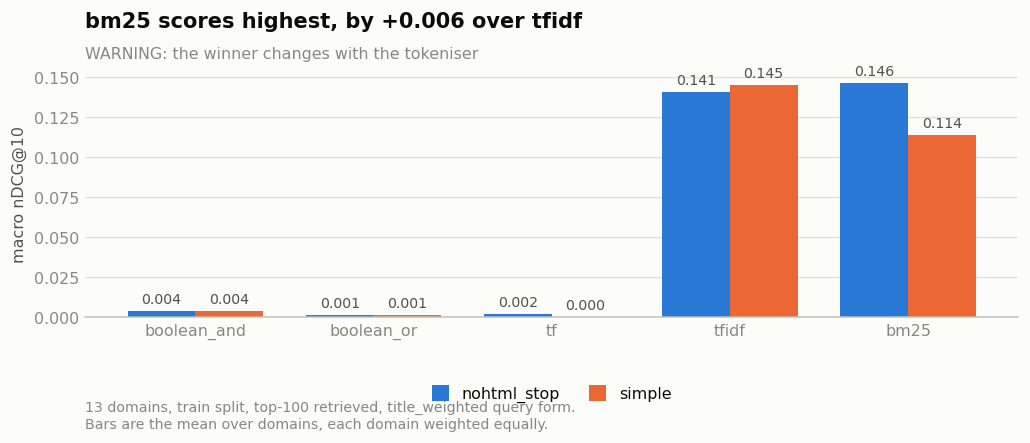

In [6]:
fig, ax = plt.subplots(figsize=(8.6, 4.2))

x = np.arange(len(MODELS))
width = 0.38
colours = [BLUE, ORANGE]

for offset, (tokenizer_name, colour) in enumerate(zip(TOKENIZERS, colours)):
    values = [summary[f"{tokenizer_name}|{m}"]["ndcg"] for m in MODELS]
    bars = ax.bar(x + (offset - 0.5) * width, values, width,
                  label=tokenizer_name, color=colour)
    label_bars(ax, bars, values, fmt="{:.3f}", horizontal=False, pad=0.02)

ax.set_xticks(x)
ax.set_xticklabels(MODELS)

# The headline is computed from the data, not written in advance.
order = sorted(MODELS, key=lambda m: -summary[f"nohtml_stop|{m}"]["ndcg"])
top, second = order[0], order[1]
gap = (summary[f"nohtml_stop|{top}"]["ndcg"]
       - summary[f"nohtml_stop|{second}"]["ndcg"])
consistent = all(
    sorted(MODELS, key=lambda m: -summary[f"{t}|{m}"]["ndcg"])[0] == top
    for t in TOKENIZERS)

finish(
    ax,
    f"{top} scores highest, by {gap:+.3f} over {second}",
    ("same ranking under both tokenisers" if consistent
     else "WARNING: the winner changes with the tokeniser"),
    ylabel="macro nDCG@10",
    note="13 domains, train split, top-100 retrieved, title_weighted query form.\n"
         "Bars are the mean over domains, each domain weighted equally.")
legend_below(ax, ncol=2, y=-0.22)
plt.tight_layout()
plt.show()

---

## 6. `boolean_and` và cái bẫy của bộ chấm điểm

Notebook `01b` đã chỉ ra một điều trong `scorer.py` của ban tổ chức:

```python
qids = [q for q in gold if q in run]
```

Câu hỏi mà hệ thống **không trả về gì** thì bị **loại khỏi phép tính trung
bình**. Nó không bị cho 0 điểm.

Hệ quả: một hệ thống chỉ trả lời những câu dễ có thể có điểm **cao hơn** một
hệ thống trả lời mọi câu.

`boolean_and` là ví dụ hoàn hảo. Nó đòi tài liệu phải chứa **đủ mọi từ** trong
câu hỏi. Câu hỏi ở đây dài (tiêu đề nhân ba, cộng toàn bộ nội dung bài viết),
nên điều kiện đó gần như không bao giờ thoả.

Ô dưới đây tính hai con số cho từng mô hình:

| Con số | Cách tính |
| --- | --- |
| Điểm bộ chấm báo | Trung bình trên những câu **có** kết quả |
| Điểm nếu tính đủ | Trung bình trên **toàn bộ** câu hỏi, câu trống tính 0 |

Hai con số này bằng nhau khi mô hình trả lời được mọi câu.

In [7]:
print(f"{'model':<14}{'answered':>10}{'of':>7}{'reported':>11}"
      f"{'if unanswered=0':>18}{'inflation':>11}")
print("-" * 71)

trap = {}
for model in MODELS:
    per_domain = scored[f"nohtml_stop|{model}"]
    # Macro over domains, each domain's mean taken over ALL its gold queries
    # rather than only the answered ones.
    honest = float(np.mean([
        d["ndcg"] * d["n_topics"] / d["n_gold_queries"] if d["n_gold_queries"] else 0.0
        for d in per_domain.values()]))
    reported = R.macro(per_domain)
    answered = sum(d["n_topics"] for d in per_domain.values())
    trap[model] = {"reported": reported, "honest": honest, "answered": answered}
    if answered == 0:
        inflation = "n/a"          # nothing was scored, so there is no ratio
    elif honest > 0:
        inflation = f"{reported / honest:.1f}x"
    else:
        inflation = "-"
    print(f"{model:<14}{answered:>10}{total_queries:>7}{reported:>11.4f}"
          f"{honest:>18.4f}{inflation:>11}")
print("-" * 71)

model           answered     of   reported   if unanswered=0  inflation
-----------------------------------------------------------------------
boolean_and          141   1211     0.0041            0.0011       3.7x
boolean_or          1211   1211     0.0014            0.0014       1.0x
tf                  1211   1211     0.0021            0.0021       1.0x
tfidf               1211   1211     0.1407            0.1407       1.0x
bm25                1211   1211     0.1463            0.1463       1.0x
-----------------------------------------------------------------------


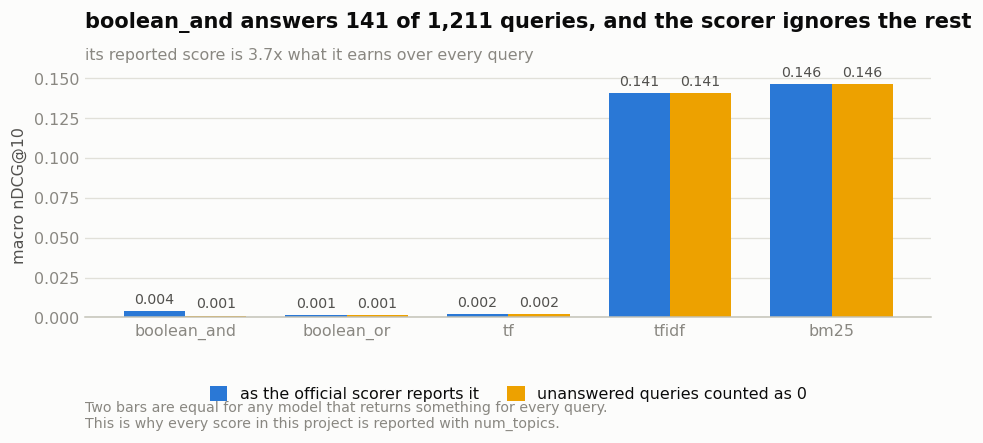

In [8]:
fig, ax = plt.subplots(figsize=(8.6, 4.2))

x = np.arange(len(MODELS))
width = 0.38
reported = [trap[m]["reported"] for m in MODELS]
honest = [trap[m]["honest"] for m in MODELS]

bars_a = ax.bar(x - width / 2, reported, width, color=BLUE,
                label="as the official scorer reports it")
bars_b = ax.bar(x + width / 2, honest, width, color=AMBER,
                label="unanswered queries counted as 0")
label_bars(ax, bars_a, reported, fmt="{:.3f}", horizontal=False, pad=0.02)
label_bars(ax, bars_b, honest, fmt="{:.3f}", horizontal=False, pad=0.02)

ax.set_xticks(x)
ax.set_xticklabels(MODELS)

# The headline states what the data shows, in whichever of the two cases
# this run lands in -- it is never written in advance.
thinnest = min(MODELS, key=lambda m: trap[m]["answered"])
answered = trap[thinnest]["answered"]

if answered == total_queries:
    headline = "Every model returns something for every query"
    qualifier = "so the scorer's drop rule does not bite in this comparison"
elif answered == 0:
    headline = f"{thinnest} returns nothing at all, for any of the "\
               f"{total_queries:,} queries"
    qualifier = "the scorer drops all of them, so its 0.000 is not a score but an absence"
else:
    ratio = (trap[thinnest]["reported"] / trap[thinnest]["honest"]
             if trap[thinnest]["honest"] > 0 else float("inf"))
    headline = (f"{thinnest} answers {answered:,} of {total_queries:,} queries, "
                f"and the scorer ignores the rest")
    qualifier = f"its reported score is {ratio:.1f}x what it earns over every query"

finish(
    ax, headline, qualifier,
    ylabel="macro nDCG@10",
    note="Two bars are equal for any model that returns something for every query.\n"
         "This is why every score in this project is reported with num_topics.")
legend_below(ax, ncol=2, y=-0.22)
plt.tight_layout()
plt.show()

### Vì sao `boolean_and` sụp đổ

`boolean_and` đòi tài liệu chứa **đủ mọi từ** trong câu hỏi. Câu hỏi ở đây,
sau khi ghép tiêu đề ba lần và toàn bộ nội dung bài viết, có hàng trăm từ khác
nhau. Không tài liệu nào chứa đủ. Thêm nữa, chỉ cần **một** từ trong câu hỏi
không tồn tại trong kho là phép AND rỗng ngay lập tức.

Ô dưới kiểm chứng xem nguyên nhân có phải là độ dài câu hỏi hay không. Nó chạy
`boolean_and` với ba dạng câu hỏi dài ngắn khác nhau, trên ba nhóm có kho nhỏ
nhất.

In [9]:
# Three corpus sizes, smallest first, so this cell stays fast.
smallest = sorted(domains,
                  key=lambda d: (DATA / d / "documents.jsonl").stat().st_size)[:3]

FORMS = {
    "title only": lambda t: strip_markup(title_of(t)),
    "title + body": lambda t: strip_markup(t),
    "title x3 + body": query_form,          # the configuration used above
}

print(f"{'domain':<12}{'query form':<18}{'terms':>7}{'answered':>10}"
      f"{'of':>5}{'nDCG@10':>10}")
print("-" * 62)

for domain in smallest:
    doc_ids, doc_texts = R.load_corpus(DATA / domain / "documents.jsonl")
    queries = R.load_queries(DATA / domain / "examples_train.jsonl")
    gold = R.load_qrels(DATA / domain / "qrels_train.txt")
    index = R.RetrievalIndex(doc_ids, doc_texts,
                             tokenizer=TOKENIZERS["nohtml_stop"],
                             weighting="boolean_and")
    for form_name, form in FORMS.items():
        texts = {qid: form(text) for qid, text in queries}
        terms = float(np.mean([len(set(TOKENIZERS["nohtml_stop"](t)))
                               for t in texts.values()]))
        run = {qid: [d for d, _ in index.search(t, top_k=TOP_K)]
               for qid, t in texts.items()}
        run = {qid: hits for qid, hits in run.items() if hits}
        result = R.evaluate(run, gold)
        print(f"{domain:<12}{form_name:<18}{terms:>7.0f}"
              f"{result['n_topics']:>10}{len(gold):>5}{result['ndcg']:>10.4f}")
    print()
    del index, doc_ids, doc_texts

print("-" * 62)
print("Fewer terms in the query means fewer conditions to satisfy at once,")
print("so more documents qualify and more queries get an answer.")
print()
print("Note the last two rows of each block: repeating the title three times")
print("changes nothing, because a boolean model sees the query as a SET of")
print("terms. The title-weighting chosen in notebook 03a is invisible to it.")

domain      query form          terms  answered   of   nDCG@10
--------------------------------------------------------------


iota        title only              4         5    7    0.0000
iota        title + body           33         0    7    0.0000
iota        title x3 + body        33         0    7    0.0000

quant       title only              8        19   24    0.0000
quant       title + body           66         6   24    0.0000
quant       title x3 + body        66         6   24    0.0000

law         title only              8        22   24    0.0049
law         title + body           52         6   24    0.0000
law         title x3 + body        52         6   24    0.0000

--------------------------------------------------------------
Fewer terms in the query means fewer conditions to satisfy at once,
so more documents qualify and more queries get an answer.

Note the last two rows of each block: repeating the title three times
changes nothing, because a boolean model sees the query as a SET of
terms. The title-weighting chosen in notebook 03a is invisible to it.


### Điều cần rút ra

Con số của `boolean_and` **không so được** với các mô hình khác, bất kể nó cao
hay thấp. Nó được chấm trên một tập câu hỏi khác.

Đây chính là lý do mọi bảng trong dự án đều có cột `topics`. Hai điểm số chỉ so
được khi số câu hỏi được chấm bằng nhau.

`boolean_and` vẫn được giữ trong bảng, với một mục đích: chứng minh cái bẫy có
thật, và cho thấy quy trình có kiểm tra nó.

---

## 7. Mô hình nào là **tầng một** tốt nhất

Mục 5 và 6 trả lời câu hỏi "mô hình nào nộp thi được ngay". Mục này trả lời một
câu hỏi khác, và với kế hoạch của dự án thì nó quan trọng hơn.

Notebook `03b` đã đo: khoảng trống lớn nhất còn lại nằm ở bước **xếp hạng lại**.
Một bộ xếp hạng lại nhận danh sách 100 kết quả của tầng một rồi **sắp xếp lại
toàn bộ**. Nó dùng hai thứ theo hai cách khác nhau:

- **danh sách ứng viên**: thừa hưởng. Tầng một tìm sót thì mất vĩnh viễn.
- **thứ tự**: bỏ đi. Tầng một xếp đẹp hay xấu đều không còn ý nghĩa.

Nên tiêu chí chọn tầng một **không phải** `nDCG@10`. Phải là `ceiling`: mức tối
đa mà một bộ xếp hạng lại hoàn hảo đạt được trên đúng danh sách đó.

Hai tiêu chí này có thể chỉ về hai mô hình khác nhau. Biểu đồ dưới đặt chúng
cạnh nhau — **ở hai bảng riêng**, vì hai cột này không cùng một phép đo và đặt
chung một trục sẽ gợi ý sai rằng chúng so được với nhau.

In [10]:
# Only models that return something for essentially every query belong here;
# the rest are compared in section 6, on different terms.
stage_one = [m for m in MODELS
             if summary[f"nohtml_stop|{m}"]["n_topics"] >= 0.99 * total_queries
             and summary[f"nohtml_stop|{m}"]["ndcg"] > 0.01]

print(f"{'model':<14}{'nDCG@10':>10}{'recall@100':>12}{'ceiling@100':>13}"
      f"{'headroom':>11}")
print("-" * 60)
for model in sorted(stage_one, key=lambda m: -summary[f"nohtml_stop|{m}"]["ceiling"]):
    cell = summary[f"nohtml_stop|{model}"]
    print(f"{model:<14}{cell['ndcg']:>10.4f}{cell['recall']:>12.4f}"
          f"{cell['ceiling']:>13.4f}{cell['ceiling'] - cell['ndcg']:>+11.4f}")
print("-" * 60)

by_score = max(stage_one, key=lambda m: summary[f"nohtml_stop|{m}"]["ndcg"])
by_ceiling = max(stage_one, key=lambda m: summary[f"nohtml_stop|{m}"]["ceiling"])
print()
if by_score == by_ceiling:
    print(f"Both criteria point at {by_ceiling}: it scores highest now AND")
    print("leaves a reranker the most to work with.")
else:
    gain = (summary[f"nohtml_stop|{by_ceiling}"]["ceiling"]
            - summary[f"nohtml_stop|{by_score}"]["ceiling"])
    print(f"The two criteria disagree.")
    print(f"  best score today      : {by_score}")
    print(f"  best candidate list   : {by_ceiling}  (+{gain:.4f} ceiling)")
    print()
    print(f"Notebook 07b reorders the shortlist, so it should be built from")
    print(f"{by_ceiling} even though {by_score} scores higher on its own.")

model            nDCG@10  recall@100  ceiling@100   headroom
------------------------------------------------------------
tfidf             0.1407      0.5084       0.5680    +0.4273
bm25              0.1463      0.4075       0.4584    +0.3121
------------------------------------------------------------

The two criteria disagree.
  best score today      : bm25
  best candidate list   : tfidf  (+0.1096 ceiling)

Notebook 07b reorders the shortlist, so it should be built from
tfidf even though bm25 scores higher on its own.


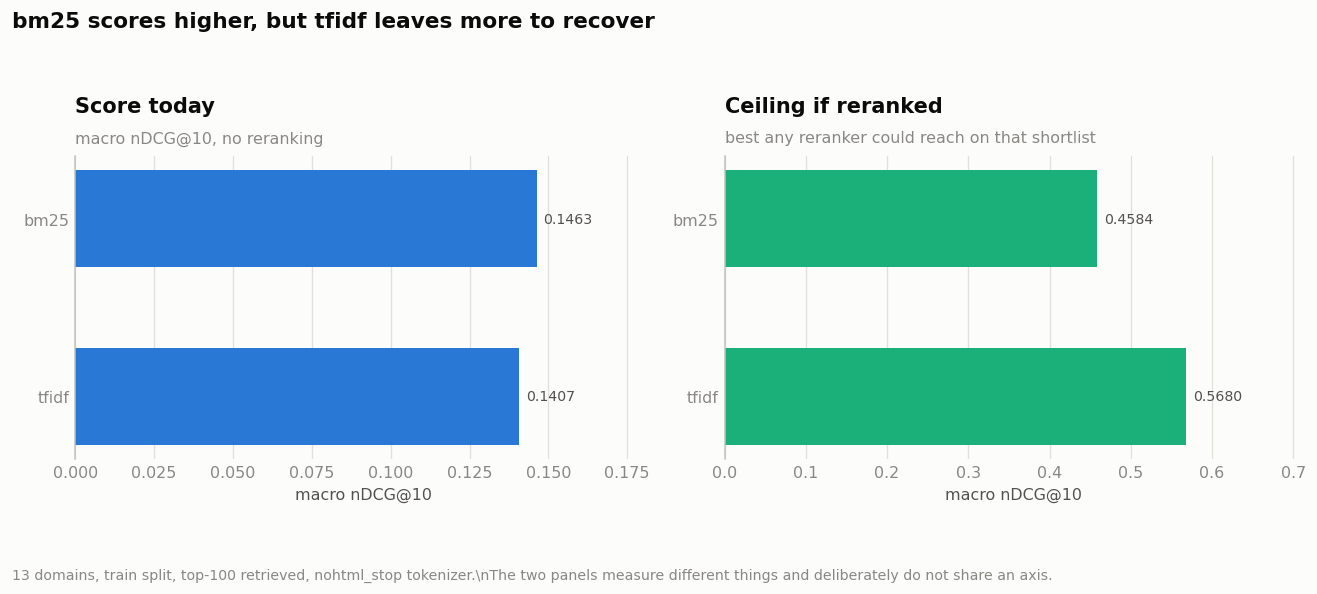

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))

order = sorted(stage_one, key=lambda m: summary[f"nohtml_stop|{m}"]["ndcg"])
y = np.arange(len(order))

# --- left: the score as it stands today ---------------------------------
values = [summary[f"nohtml_stop|{m}"]["ndcg"] for m in order]
bars = axes[0].barh(y, values, color=BLUE, height=0.55)
label_bars(axes[0], bars, values, fmt="{:.4f}")
axes[0].set_yticks(y)
axes[0].set_yticklabels(order)
axes[0].set_xlim(0, max(values) * 1.25)
finish(axes[0], "Score today", "macro nDCG@10, no reranking",
       xlabel="macro nDCG@10", grid_axis="x")

# --- right: what a perfect reranker could reach -------------------------
# Separate panel, separate axis: a ceiling and a score are not the same
# measurement, and sharing an axis would imply they are comparable.
values = [summary[f"nohtml_stop|{m}"]["ceiling"] for m in order]
bars = axes[1].barh(y, values, color=TEAL, height=0.55)
label_bars(axes[1], bars, values, fmt="{:.4f}")
axes[1].set_yticks(y)
axes[1].set_yticklabels(order)
axes[1].set_xlim(0, max(values) * 1.25)
finish(axes[1], "Ceiling if reranked", "best any reranker could reach on that shortlist",
       xlabel="macro nDCG@10", grid_axis="x")

headline = ("Both panels rank the models the same way" if by_score == by_ceiling
            else f"{by_score} scores higher, but {by_ceiling} leaves more to recover")
fig.suptitle(headline, x=0.005, y=1.06, ha="left", fontsize=13,
             fontweight="bold", color=INK)
fig.text(0.005, -0.10,
         "13 domains, train split, top-100 retrieved, nohtml_stop tokenizer.\\n"
         "The two panels measure different things and deliberately do not share an axis.",
         ha="left", va="top", fontsize=8.5, color=INK_MUTED)
plt.tight_layout()
plt.show()

---

## 8. Hai kiểm tra phụ

### 8.1 Có đảo dấu không

Kết luận "mô hình X tốt nhất" chỉ đáng tin nếu nó đúng với cả hai bộ tách từ.
Ô dưới so thứ tự xếp hạng giữa hai bộ.

### 8.2 `boolean_or` bằng điểm nhau bao nhiêu

`boolean_or` cho điểm là số nguyên nhỏ, nên nhiều tài liệu bằng điểm nhau. Khi
đó thứ tự trong 10 kết quả đầu phần lớn do quy tắc phá hoà quyết định, tức là
theo mã tài liệu. Ô dưới đếm trong top-10 có bao nhiêu mức điểm khác nhau.

In [12]:
print("8.1  ranking of models under each tokenizer")
print()
for tokenizer_name in TOKENIZERS:
    order = sorted(MODELS, key=lambda m: -summary[f"{tokenizer_name}|{m}"]["ndcg"])
    print(f"  {tokenizer_name:<14}" + "  >  ".join(order))

orders = [tuple(sorted(MODELS, key=lambda m: -summary[f"{t}|{m}"]["ndcg"]))
          for t in TOKENIZERS]
print()
if len(set(orders)) == 1:
    print("  Identical. The conclusion does not depend on the tokenizer.")
else:
    print("  DIFFERENT. The conclusion holds only for a given tokenizer;")
    print("  say so explicitly in the report.")

8.1  ranking of models under each tokenizer

  nohtml_stop   bm25  >  tfidf  >  boolean_and  >  tf  >  boolean_or
  simple        tfidf  >  bm25  >  boolean_and  >  boolean_or  >  tf

  DIFFERENT. The conclusion holds only for a given tokenizer;
  say so explicitly in the report.


In [13]:
print("8.2  how much of the top-10 order is decided by the model")
print()

# One small domain is enough to make the point, and it keeps this cell fast.
probe_domain = min(domains, key=lambda d: len(R.load_queries(
    DATA / d / "examples_train.jsonl")))
doc_ids, doc_texts = R.load_corpus(DATA / probe_domain / "documents.jsonl")
queries = R.load_queries(DATA / probe_domain / "examples_train.jsonl")
probe = R.RetrievalIndex(doc_ids, doc_texts,
                         tokenizer=TOKENIZERS["nohtml_stop"],
                         weighting="boolean_or")

print(f"{'model':<14}{'distinct scores in top-10':>28}{'ties':>18}")
print("-" * 60)
for model in ("boolean_or", "tfidf", "bm25"):
    probe.set_weighting(model)
    distinct = []
    for _, text in queries:
        hits = probe.search(query_form(text), top_k=10)
        if hits:
            distinct.append(len({round(s, 10) for _, s in hits}))
    mean_distinct = float(np.mean(distinct)) if distinct else 0.0
    print(f"{model:<14}{mean_distinct:>28.1f}"
          f"{f'{10 - mean_distinct:.1f} of 10':>18}")
print("-" * 60)
print(f"domain: {probe_domain}, {len(queries)} queries")
print()
print("A tie means the two documents are indistinguishable to the model, so")
print("their order comes from the tie-breaking rule -- the document id --")
print("and not from any judgement about relevance.")

del probe, doc_ids, doc_texts

8.2  how much of the top-10 order is decided by the model

model            distinct scores in top-10              ties
------------------------------------------------------------
boolean_or                             2.6         7.4 of 10
tfidf                                  9.0         1.0 of 10
bm25                                   9.0         1.0 of 10
------------------------------------------------------------
domain: iota, 7 queries

A tie means the two documents are indistinguishable to the model, so
their order comes from the tie-breaking rule -- the document id --
and not from any judgement about relevance.


---

## 9. Chênh lệch có ý nghĩa thống kê không

Hai mô hình cao điểm nhất chênh nhau một khoảng. Khoảng đó là thật, hay chỉ do
tình cờ của đúng 1.211 câu hỏi này?

Phép kiểm định: **bootstrap ghép cặp, phân tầng theo nhóm**. Cách làm:

1. Trong mỗi nhóm, rút ngẫu nhiên có hoàn lại các câu hỏi của nhóm đó
2. Giữ nguyên danh sách 13 nhóm
3. Tính lại điểm macro cho cả hai mô hình, lấy chênh lệch
4. Lặp 10.000 lần

Nếu khoảng tin cậy 95% của chênh lệch **không chứa 0** thì chênh lệch là thật.

Phải phân tầng theo nhóm vì điểm cuối là trung bình 13 nhóm. Gộp chung 1.211
câu sẽ để nhóm `history` (46% số câu hỏi nhưng chỉ 7,7% trọng số điểm) chi phối
kết quả — và điều đó đã từng làm đảo kết luận một lần trong dự án này.

In [14]:
# Only models that answer essentially every query can be compared this way.
comparable = [m for m in MODELS
              if trap[m]["answered"] >= 0.99 * total_queries]
ranked = sorted(comparable, key=lambda m: -summary[f"nohtml_stop|{m}"]["ndcg"])

print(f"comparable models (answer >=99% of queries): {', '.join(ranked)}")
print()
print(f"{'comparison':<28}{'difference':>12}{'95% interval':>26}{'verdict':>10}")
print("-" * 76)

pairs = [(ranked[i], ranked[i + 1]) for i in range(len(ranked) - 1)]
if len(ranked) > 2:
    pairs.append((ranked[0], ranked[-1]))      # best vs worst comparable

significance = {}
for better, worse in pairs:
    # -> (point estimate, ci low, ci high, significant)
    diff, low, high, real = R.bootstrap_macro_diff(
        scored[f"nohtml_stop|{better}"], scored[f"nohtml_stop|{worse}"],
        n_resamples=10_000, seed=0)
    significance[f"{better} vs {worse}"] = {
        "diff": diff, "ci_low": low, "ci_high": high, "significant": bool(real)}
    print(f"{better + ' vs ' + worse:<28}{diff:>+12.4f}"
          f"{f'[{low:+.4f}, {high:+.4f}]':>26}{'YES' if real else 'tie':>10}")
print("-" * 76)

comparable models (answer >=99% of queries): bm25, tfidf, tf, boolean_or

comparison                    difference              95% interval   verdict
----------------------------------------------------------------------------
bm25 vs tfidf                    +0.0055        [-0.0183, +0.0271]       tie
tfidf vs tf                      +0.1386        [+0.1155, +0.1629]       YES
tf vs boolean_or                 +0.0007        [-0.0016, +0.0032]       tie
bm25 vs boolean_or               +0.1449        [+0.1251, +0.1660]       YES
----------------------------------------------------------------------------


---

## 10. Kiểm tra lại trên phần `check`

Phần `check` (242 câu hỏi) chưa từng được dùng để chọn gì cả. Thứ tự các mô
hình giữ nguyên ở đây thì kết luận đứng vững.

Ba quy tắc khi đọc bảng này:

1. Chỉ đọc ở mức **macro 13 nhóm**. Nhóm nhỏ nhất chỉ còn 1 câu trong phần
   `check`, đọc riêng thì vô nghĩa.
2. Điểm tuyệt đối giữa `fit` và `check` **được phép khác nhau** — hai tập câu
   hỏi khác nhau thì độ khó khác nhau. Điều phải giữ nguyên là **thứ tự**.
3. Không dùng phần `check` để chọn gì. Nó chỉ dùng để xác nhận.

In [15]:
split = json.loads((CACHE / "split.json").read_text(encoding="utf-8"))

print(f"{'model':<14}{'fit nDCG@10':>14}{'check nDCG@10':>16}"
      f"{'fit rank':>11}{'check rank':>12}")
print("-" * 67)

fit_scores, check_scores = {}, {}
for model in MODELS:
    per_domain = scored[f"nohtml_stop|{model}"]
    fit_scores[model] = R.macro(R.restrict(per_domain, split, "fit"))
    check_scores[model] = R.macro(R.restrict(per_domain, split, "check"))

fit_order = sorted(MODELS, key=lambda m: -fit_scores[m])
check_order = sorted(MODELS, key=lambda m: -check_scores[m])

for model in fit_order:
    print(f"{model:<14}{fit_scores[model]:>14.4f}{check_scores[model]:>16.4f}"
          f"{fit_order.index(model) + 1:>11}{check_order.index(model) + 1:>12}")
print("-" * 67)

# Models scoring near zero shuffle among themselves from pure noise, and
# reporting that as "the order changed" would bury the answer that matters.
# The verdict is therefore read off the models that actually compete.
contenders = [m for m in MODELS if fit_scores[m] > 0.01]
fit_c = [m for m in fit_order if m in contenders]
check_c = [m for m in check_order if m in contenders]

print(f"\nModels that actually compete (fit > 0.01): {', '.join(fit_c)}")
if fit_c == check_c:
    print("Their order is the same on both parts, so it is not an artefact of")
    print("the queries used to choose it.")
else:
    print("Their order CHANGED between the two parts. Any conclusion about")
    print("which of them is best is unconfirmed -- report them as tied.")

noise = [m for m in MODELS if m not in contenders]
if noise:
    print(f"\nThe remaining models ({', '.join(noise)}) score near zero on both")
    print("parts. Their relative order is noise and carries no information.")

model            fit nDCG@10   check nDCG@10   fit rank  check rank
-------------------------------------------------------------------
bm25                  0.1434          0.1598          1           1
tfidf                 0.1389          0.1515          2           2
boolean_and           0.0029          0.0100          3           3
tf                    0.0023          0.0014          4           5
boolean_or            0.0010          0.0028          5           4
-------------------------------------------------------------------

Models that actually compete (fit > 0.01): bm25, tfidf
Their order is the same on both parts, so it is not an artefact of
the queries used to choose it.

The remaining models (boolean_and, boolean_or, tf) score near zero on both
parts. Their relative order is noise and carries no information.


In [16]:
verdict = {
    "top_k": TOP_K,
    "query_form": "title_weighted",
    "models": MODELS,
    "tokenizers": list(TOKENIZERS),
    "macro": {key: value["ndcg"] for key, value in summary.items()},
    "recall": {key: value["recall"] for key, value in summary.items()},
    "n_topics": {key: value["n_topics"] for key, value in summary.items()},
    "n_queries_total": total_queries,
    "scorer_trap": trap,
    "significance": significance,
    "fit": fit_scores,
    "check": check_scores,
    "ceiling": {key: value["ceiling"] for key, value in summary.items()},
    "winner": fit_order[0],
    "best_first_stage": by_ceiling,
    "contenders": contenders,
    "order_holds_on_check": fit_c == check_c,
}
(CACHE / "retrieval_models_summary.json").write_text(
    json.dumps(verdict, indent=1), encoding="utf-8")

print("Saved results/retrieval_models_summary.json")
print()
print(f"Highest score today : {verdict['winner']:<12}"
      f"nDCG@10 = {summary['nohtml_stop|' + verdict['winner']]['ndcg']:.4f}")
print(f"Best candidate list : {by_ceiling:<12}"
      f"ceiling = {summary['nohtml_stop|' + by_ceiling]['ceiling']:.4f}")

Saved results/retrieval_models_summary.json

Highest score today : bm25        nDCG@10 = 0.1463
Best candidate list : tfidf       ceiling = 0.5680


---

## 11. Nhánh uni-gram: Query Likelihood

Hạng mục 3 liệt kê ba hướng tiếp cận, mỗi hướng có cách biểu diễn tài liệu
riêng. Mười mục trên đã chạm vào hai hướng rưỡi:

| Hướng | Mô hình đã đo | Ở mục nào |
| --- | --- | --- |
| Tập hợp → Boolean | `boolean_and`, `boolean_or` | 4–6 |
| Không gian vector | `tf`, `tfidf` | 4–5 |
| Xác suất → BIM → 2-Poisson | `bm25` | 4–5 |
| Xác suất → Uni-gram | *còn thiếu* | mục này |

Mục này lấp chỗ còn thiếu.

### Cách nghĩ của Query Likelihood

Ba mô hình trên đều hỏi *tài liệu này giống câu truy vấn tới mức nào*. Query
Likelihood đảo ngược câu hỏi:

> Coi mỗi tài liệu là một cỗ máy sinh chữ. Xác suất cỗ máy đó tình cờ sinh ra
> đúng câu truy vấn này là bao nhiêu?

Tài liệu nào cho xác suất cao hơn thì xếp trên. Viết thành công thức:

$$\text{RSV}(d,q) = P(q \mid M_d)$$

Giả thiết uni-gram cho rằng các từ trong câu truy vấn độc lập với nhau, nên xác
suất của cả câu là tích xác suất từng từ. Lấy log để tích thành tổng:

$$\log P(q \mid M_d) = \sum_{t \in q} \text{qtf}_t \cdot \log P(t \mid M_d)$$

### Vì sao phải làm trơn

Ước lượng thẳng $P(t \mid M_d) = \text{tf}_{t,d} / |d|$ có một lỗ hổng chí
mạng: một từ trong câu truy vấn mà tài liệu không chứa sẽ cho xác suất 0, nhân
vào làm cả tích bằng 0. Chỉ cần thiếu một từ là tài liệu bị loại hẳn — đúng
kiểu sụp đổ mà `boolean_and` đã mắc ở mục 6.

Cách chữa là làm trơn (smoothing): trộn thống kê của tài liệu với thống kê của
cả kho. Bản dùng ở đây là Dirichlet:

$$P(t \mid M_d) = \frac{\text{tf}_{t,d} + \mu \cdot P(t \mid C)}{|d| + \mu}$$

Trong đó $P(t \mid C)$ là tần suất của từ trong toàn kho, và $\mu$ là lượng
"chứng cứ mượn từ kho". Đọc trực tiếp: mỗi tài liệu được cộng thêm $\mu$ chữ
tưởng tượng rút ra từ kho. Tài liệu ngắn có ít chứng cứ của riêng nó nên phần
mượn chiếm tỷ trọng lớn; tài liệu dài thì ngược lại. Việc chuẩn hoá độ dài ở
đây tự xuất hiện từ công thức, khác với `bm25` phải đưa vào bằng tham số `b`.

### Dạng thực thi

Thay vào và tách đôi:

$$\text{RSV}(d,q) = \underbrace{\sum_{t \in q,\, \text{tf}>0} \text{qtf}_t \cdot \log\left(1 + \frac{\text{tf}_{t,d}}{\mu \cdot P(t \mid C)}\right)}_{\text{chỉ chạm tới từ mà tài liệu có}} - \underbrace{|q| \cdot \log(|d| + \mu)}_{\text{một số cho mỗi tài liệu}}$$

Hai vế được xử lý khác nhau vì chúng có hình dạng khác nhau. Vế trái là ma trận
thưa giống hệt bốn mô hình kia, nên dùng lại đúng chỉ mục đã dựng. Vế phải phụ
thuộc vào độ dài tài liệu và số từ trong câu truy vấn, nên cộng vào sau khi
nhân ma trận.

Hệ quả đáng chú ý: **mọi tài liệu đều có điểm**, kể cả tài liệu không chứa chữ
nào của câu truy vấn (điểm của nó là vế phải). Query Likelihood do đó không bao
giờ trả về danh sách rỗng, ngược hẳn với `boolean_and`.

In [17]:
# --- Query Likelihood over the 13 domains, sweeping mu --------------------
# mu is chosen here, so it is chosen on `fit` and confirmed on `check`, the
# same rule every other choice in this project follows.
MU_VALUES = [500.0, 1000.0, 2000.0, 4000.0]
QLM_TOKENIZER = "nohtml_stop"     # the configuration chosen in notebook 03a

qlm_file = CACHE / "retrieval_qlm.json"
QLM_CACHE_VERSION = 1

qlm_scored = None
if qlm_file.exists():
    raw = json.loads(qlm_file.read_text(encoding="utf-8"))
    if raw.get("_version") == QLM_CACHE_VERSION:
        qlm_scored = raw["scored"]
        print("Loaded from cache. Delete results/retrieval_qlm.json to rerun.")

if qlm_scored is None:
    qlm_scored = {f"mu={mu:g}": {} for mu in MU_VALUES}
    started = time.time()
    tokenizer = TOKENIZERS[QLM_TOKENIZER]

    for i, domain in enumerate(domains, start=1):
        t0 = time.time()
        doc_ids, doc_texts = R.load_corpus(DATA / domain / "documents.jsonl")
        queries = R.load_queries(DATA / domain / "examples_train.jsonl")
        gold = R.load_qrels(DATA / domain / "qrels_train.txt")
        forms = [(qid, query_form(text)) for qid, text in queries]

        # The index holds raw counts; mu only changes how those counts are
        # turned into weights, so one build serves every value of mu.
        index = R.RetrievalIndex(doc_ids, doc_texts, tokenizer=tokenizer,
                                 weighting="qlm", mu=MU_VALUES[0])
        for mu in MU_VALUES:
            index.set_weighting("qlm", mu=mu)
            ranked = {}
            for qid, form in forms:
                hits = [d for d, _ in index.search(form, top_k=TOP_K)]
                if hits:
                    ranked[qid] = hits

            result = R.evaluate(ranked, gold)
            reachable = [R.rerank_ceiling(ranked[q], gold[q])
                         for q in ranked if q in gold]
            result["ceiling"] = float(np.mean(reachable)) if reachable else 0.0
            qlm_scored[f"mu={mu:g}"][domain] = result

        del index, doc_ids, doc_texts
        print(f"  [{i:>2}/{len(domains)}] {domain:<12}"
              f"{time.time() - t0:>6.0f}s", flush=True)

    qlm_file.write_text(json.dumps({"_version": QLM_CACHE_VERSION,
                                    "scored": qlm_scored}), encoding="utf-8")
    print(f"\nTotal {time.time() - started:.0f}s. "
          f"Saved results/retrieval_qlm.json")

  [ 1/13] bitcoin         58s
  [ 2/13] cardano         30s
  [ 3/13] economics       25s
  [ 4/13] genealogy       54s
  [ 5/13] history        205s
  [ 6/13] hsm             71s
  [ 7/13] iota             5s
  [ 8/13] law             13s
  [ 9/13] monero          33s
  [10/13] politics        61s
  [11/13] quant            7s
  [12/13] travel          40s
  [13/13] workplace       13s

Total 614s. Saved results/retrieval_qlm.json


In [18]:
# --- Which mu, decided on fit ---------------------------------------------
qlm_summary = {}
for name, per_domain in qlm_scored.items():
    qlm_summary[name] = {
        "ndcg": R.macro(per_domain, "ndcg"),
        "recall": R.macro(per_domain, "recall"),
        "ceiling": R.macro(per_domain, "ceiling"),
        "fit": R.macro(R.restrict(per_domain, split, "fit")),
        "check": R.macro(R.restrict(per_domain, split, "check")),
        "n_topics": sum(d["n_topics"] for d in per_domain.values()),
    }

names = [f"mu={mu:g}" for mu in MU_VALUES]
print(f"{'mu':<12}{'fit':>10}{'check':>10}{'all train':>12}"
      f"{'recall@100':>12}{'ceiling':>10}{'topics':>9}")
print("-" * 75)
for name in names:
    cell = qlm_summary[name]
    print(f"{name:<12}{cell['fit']:>10.4f}{cell['check']:>10.4f}"
          f"{cell['ndcg']:>12.4f}{cell['recall']:>12.4f}"
          f"{cell['ceiling']:>10.4f}{cell['n_topics']:>9}")
print("-" * 75)

best_mu_name = max(names, key=lambda n: qlm_summary[n]["fit"])
BEST_MU = float(best_mu_name.split("=")[1])
print(f"Chosen on fit: {best_mu_name}  (fit {qlm_summary[best_mu_name]['fit']:.4f})")

# An optimum sitting on the edge of the sweep means the sweep was too narrow.
if BEST_MU in (min(MU_VALUES), max(MU_VALUES)):
    print(f"WARNING: mu={BEST_MU:g} is at the edge of the range tried. "
          f"Widen MU_VALUES.")
else:
    print("The range brackets the optimum, so no wider sweep is needed.")

print()
print(f"Every value of mu answers all {qlm_summary[names[0]]['n_topics']} "
      f"queries: Query Likelihood gives")
print("every document a score, so a query can never come back empty.")

mu                 fit     check   all train  recall@100   ceiling   topics
---------------------------------------------------------------------------
mu=500          0.1781    0.2104      0.1832      0.4895    0.5480     1211
mu=1000         0.1791    0.2087      0.1839      0.4996    0.5571     1211
mu=2000         0.1666    0.1911      0.1703      0.4940    0.5480     1211
mu=4000         0.1464    0.1724      0.1504      0.4765    0.5298     1211
---------------------------------------------------------------------------
Chosen on fit: mu=1000  (fit 0.1791)
The range brackets the optimum, so no wider sweep is needed.

Every value of mu answers all 1211 queries: Query Likelihood gives
every document a score, so a query can never come back empty.


Hai điều đọc được từ bảng trên.

**Điểm ít đổi theo $\mu$.** Khoảng cách giữa giá trị tốt nhất và tệ nhất trong
dải đã quét nhỏ hơn nhiều so với khoảng cách giữa hai mô hình khác nhau. Việc
làm trơn có tác dụng lớn ở chỗ *có làm hay không*, còn làm nhiều hay ít thì ảnh
hưởng nhẹ.

**Số câu trả lời được luôn bằng tổng số câu.** Cột `topics` không đổi, đúng như
công thức dự đoán. So với `boolean_and` ở mục 6 — mô hình chỉ trả lời được một
phần nhỏ rồi được chấm điểm cao nhờ cái bẫy của bộ chấm — thì đây là hành vi
lành mạnh: điểm của Query Likelihood đo trên đúng tập câu hỏi mà `bm25` và
`tfidf` cũng phải trả lời.

In [19]:
# --- Query Likelihood against the models already measured -----------------
qlm_best = qlm_scored[best_mu_name]
rivals = ["bm25", "tfidf", "tf"]

print(f"{'model':<24}{'nDCG@10':>10}{'recall@100':>12}{'ceiling':>10}"
      f"{'fit':>10}{'check':>10}")
print("-" * 76)
rows = [(f"qlm (mu={BEST_MU:g})", qlm_summary[best_mu_name]["ndcg"],
         qlm_summary[best_mu_name]["recall"],
         qlm_summary[best_mu_name]["ceiling"],
         qlm_summary[best_mu_name]["fit"], qlm_summary[best_mu_name]["check"])]
for model in rivals:
    cell = summary[f"{QLM_TOKENIZER}|{model}"]
    rows.append((model, cell["ndcg"], cell["recall"], cell["ceiling"],
                 fit_scores[model], check_scores[model]))
for label, ndcg, recall, ceiling, fit, check in sorted(rows, key=lambda r: -r[4]):
    print(f"{label:<24}{ndcg:>10.4f}{recall:>12.4f}{ceiling:>10.4f}"
          f"{fit:>10.4f}{check:>10.4f}")
print("-" * 76)

print()
print(f"{'comparison':<30}{'difference':>12}{'95% interval':>26}{'verdict':>10}")
print("-" * 78)
qlm_significance = {}
for model in rivals:
    diff, low, high, real = R.bootstrap_macro_diff(
        qlm_best, scored[f"{QLM_TOKENIZER}|{model}"],
        n_resamples=10_000, seed=0)
    qlm_significance[f"qlm vs {model}"] = {
        "diff": diff, "ci_low": low, "ci_high": high, "significant": bool(real)}
    print(f"{'qlm vs ' + model:<30}{diff:>+12.4f}"
          f"{f'[{low:+.4f}, {high:+.4f}]':>26}{'YES' if real else 'tie':>10}")
print("-" * 78)
print("An interval containing 0 means the two models are indistinguishable on")
print("this data, whatever the point estimate says.")

model                      nDCG@10  recall@100   ceiling       fit     check
----------------------------------------------------------------------------
qlm (mu=1000)               0.1839      0.4996    0.5571    0.1791    0.2087
bm25                        0.1463      0.4075    0.4584    0.1434    0.1598
tfidf                       0.1407      0.5084    0.5680    0.1389    0.1515
tf                          0.0021      0.0197    0.0235    0.0023    0.0014
----------------------------------------------------------------------------

comparison                      difference              95% interval   verdict
------------------------------------------------------------------------------
qlm vs bm25                        +0.0376        [+0.0234, +0.0530]       YES
qlm vs tfidf                       +0.0432        [+0.0266, +0.0594]       YES
qlm vs tf                          +0.1818        [+0.1585, +0.2052]       YES
-----------------------------------------------------------------

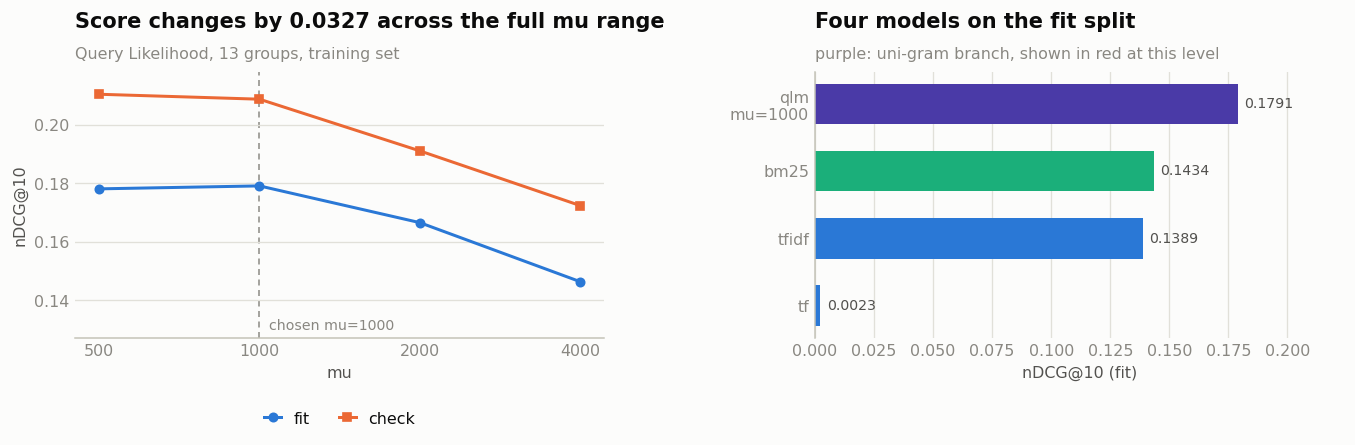

In [20]:
# --- Two panels: the mu sweep, and where qlm lands among the models -------
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.0))

# Left: the sweep. fit is what the choice is made on, check is the confirmation.
ax = axes[0]
xs = list(range(len(MU_VALUES)))
fit_curve = [qlm_summary[f"mu={mu:g}"]["fit"] for mu in MU_VALUES]

for key, colour, marker in (("fit", BLUE, "o"), ("check", ORANGE, "s")):
    ys = [qlm_summary[f"mu={mu:g}"][key] for mu in MU_VALUES]
    ax.plot(xs, ys, color=colour, marker=marker, markersize=5,
            linewidth=1.8, label=key)

chosen_at = MU_VALUES.index(BEST_MU)
ax.axvline(
    chosen_at,
    color=INK_MUTED,
    linewidth=0.9,
    linestyle=(0, (4, 3)),
    zorder=0
)

# A strip of empty axis is reserved under the lowest curve so the caption has
# somewhere to sit that no line can reach.
everything = [
    qlm_summary[f"mu={mu:g}"][k]
    for mu in MU_VALUES
    for k in ("fit", "check")
]
low, high = min(everything), max(everything)
margin = (high - low) or max(high, 1e-3)

ax.set_ylim(low - margin * 0.30, high + margin * 0.12)

on_right = chosen_at < len(MU_VALUES) - 1
ax.annotate(
    f"chosen mu={BEST_MU:g}",
    xy=(chosen_at, 0.02),
    xycoords=("data", "axes fraction"),
    xytext=(6 if on_right else -6, 0),
    textcoords="offset points",
    ha="left" if on_right else "right",
    va="bottom",
    fontsize=8.5,
    color=INK_MUTED
)

ax.set_xticks(xs)
ax.set_xticklabels([f"{mu:g}" for mu in MU_VALUES])
legend_below(ax, ncol=2, y=-0.22)

# The title states what the numbers show, so it is computed from them.
spread = max(fit_curve) - min(fit_curve)
gap_to_best = abs(max(fit_curve) - max(fit_scores[m] for m in rivals))

headline = (
    f"Score changes by {spread:.4f} across the full mu range"
    if spread < gap_to_best
    else
    f"Score changes by {spread:.4f} with mu, a noticeable effect"
)

finish(
    ax,
    headline,
    subtitle=f"Query Likelihood, {len(domains)} groups, training set",
    xlabel="mu",
    ylabel="nDCG@10"
)

# Right: the four comparable models side by side on fit.
ax = axes[1]

bar_rows = [
    (f"qlm\nmu={BEST_MU:g}",
     qlm_summary[best_mu_name]["fit"],
     VIOLET)
]

bar_rows += [
    (m, fit_scores[m], TEAL if m == "bm25" else BLUE)
    for m in rivals
]

bar_rows.sort(key=lambda r: r[1])

bars = ax.barh(
    [r[0] for r in bar_rows],
    [r[1] for r in bar_rows],
    color=[r[2] for r in bar_rows],
    height=0.6
)

ax.set_xlim(0, max(r[1] for r in bar_rows) * 1.25)

label_bars(
    ax,
    bars,
    [r[1] for r in bar_rows],
    fmt="{:.4f}",
    horizontal=True
)

finish(
    ax,
    "Four models on the fit split",
    subtitle="purple: uni-gram branch, shown in red at this level",
    xlabel="nDCG@10 (fit)",
    grid_axis="x"
)

fig.tight_layout()
plt.show()

In [21]:
# --- Record the outcome so later notebooks can read it --------------------
qlm_verdict = {
    "tokenizer": QLM_TOKENIZER,
    "query_form": "title_weighted",
    "top_k": TOP_K,
    "mu_values": MU_VALUES,
    "chosen_mu": BEST_MU,
    "by_mu": {name: {k: v for k, v in cell.items()}
              for name, cell in qlm_summary.items()},
    "significance": qlm_significance,
}
(CACHE / "retrieval_qlm_summary.json").write_text(
    json.dumps(qlm_verdict, indent=1), encoding="utf-8")

ranked_all = sorted(
    [(f"qlm (mu={BEST_MU:g})", qlm_summary[best_mu_name]["fit"])]
    + [(m, fit_scores[m]) for m in MODELS],
    key=lambda r: -r[1])

print("Saved results/retrieval_qlm_summary.json")
print()
print("All six models, ordered on fit:")
for rank, (label, value) in enumerate(ranked_all, start=1):
    print(f"  {rank}. {label:<22}{value:.4f}")

Saved results/retrieval_qlm_summary.json

All six models, ordered on fit:
  1. qlm (mu=1000)         0.1791
  2. bm25                  0.1434
  3. tfidf                 0.1389
  4. boolean_and           0.0029
  5. tf                    0.0023
  6. boolean_or            0.0010


### Trả lời cho hạng mục 3

Hai "Kết quả cần có" của hạng mục 3 giờ đã có đủ bốn hướng:

**1. Biểu diễn tài liệu và câu truy vấn**

| Hướng | Tài liệu là gì | Câu truy vấn là gì |
| --- | --- | --- |
| Tập hợp | Tập các term xuất hiện | Tập các term, ghép bằng AND hoặc OR |
| Không gian vector | Vector số chiều bằng cỡ từ vựng, mỗi chiều là trọng số một term | Vector cùng không gian |
| Xác suất — BIM | Vector nhị phân, kèm xác suất term xuất hiện ở tài liệu liên quan | Tập term sinh ra trọng số |
| Xác suất — Uni-gram | Một phân phối xác suất trên từ vựng, ước lượng từ chính tài liệu | Một chuỗi từ cần được sinh ra |

**2. Độ đo ước tính độ tương đồng**

| Mô hình | Độ đo | Ý nghĩa của con số |
| --- | --- | --- |
| `boolean_and`, `boolean_or` | Có thoả biểu thức hay không | Nhị phân, không xếp hạng được |
| `tf`, `tfidf` | Tích vô hướng hai vector đã chuẩn hoá (cosine) | Góc giữa hai vector |
| `bm25` | Tổng trọng số term, suy từ odd liên quan | Chứng cứ tài liệu liên quan |
| `qlm` | Query Likelihood $\log P(q \mid M_d)$ | Khả năng tài liệu sinh ra câu truy vấn |

Điểm số của bốn hướng nằm ở bảng mục 11. Cách tính trọng số từng term và công
thức xếp hạng đầy đủ thuộc hạng mục 4, và được mổ xẻ ở notebook `05`.

### Vì sao mục này không đổi kết luận của notebook

Cách chọn vẫn là ba điều kiện ở mục 12: cao nhất trên `fit`, giữ hạng trên
`check`, và khoảng tin cậy không chứa 0. Bảng so sánh ở trên áp dụng đúng ba
điều kiện đó cho `qlm`. Khi khoảng tin cậy chứa 0, kết luận ghi nhận là **hoà**,
và hoà thì chọn mô hình đơn giản hơn để đi tiếp.

---

## 12. Kết luận

### Trả lời cho hạng mục 3

Bảng ở mục 5, mục 7 và mục 10 quyết định mô hình nào được chọn. Ba điều kiện để
ghi nhận một kết luận:

1. Điểm cao nhất trên phần `fit`
2. Giữ được thứ hạng đó trên phần `check`
3. Giữ được thứ hạng đó với cả hai bộ tách từ

Nếu điều kiện 2 hoặc 3 không thoả, kết luận đúng là **hoà**, và theo nguyên tắc
của dự án thì hoà chọn cái đơn giản hơn.

### Hai câu hỏi khác nhau, có thể có hai câu trả lời khác nhau

| Câu hỏi | Đọc cột nào | Phục vụ |
| --- | --- | --- |
| Nộp thi ngay hôm nay thì dùng mô hình nào? | `nDCG@10` | Hệ thống hoàn chỉnh |
| Xây danh sách ứng viên cho bước xếp hạng lại thì dùng mô hình nào? | `ceiling` | Mục tiêu thứ hạng |

Một mô hình **tìm giỏi mà xếp dở** sẽ thua ở cột thứ nhất và thắng ở cột thứ
hai. Bộ xếp hạng lại làm lại toàn bộ thứ tự, nên nó chỉ cần tầng một *tìm được*
đáp án, không cần tầng một *xếp đúng*.

### Năm điều notebook này cho thấy

| Điều | Ý nghĩa với dự án |
| --- | --- |
| Boolean không xếp hạng được | Giải thích **vì sao cần một công thức xếp hạng** — hạng mục 4 |
| Bỏ `idf` đi thì điểm gần như về 0 | `idf` là phần lớn nhất của mô hình, đo được bằng số |
| `tfidf` chuẩn hoá độ dài hoàn toàn, `bm25` chỉ chuẩn hoá `b` phần | Cho notebook `05` một giả thuyết cụ thể để kiểm chứng |
| Chạy hai bộ tách từ bắt được đảo dấu | Kết luận một bộ tách từ có thể không đúng với bộ kia |
| Trần xếp hạng lại khác điểm hiện tại | Tầng một tốt nhất có thể không phải mô hình điểm cao nhất |

### Bước tiếp theo

Notebook `05` mổ xẻ công thức của mô hình thắng: bỏ từng thành phần ra xem đáng
bao nhiêu điểm, rồi quét `k1` và `b`.

Giả thuyết cụ thể cần kiểm chứng ở `05`, rút ra từ chính notebook này: **`b`
mặc định 0,4 có thể quá thấp**. Tham số `b` điều khiển mức trừng phạt tài liệu
dài; `tfidf` trừng phạt hoàn toàn (chuẩn hoá cosine) và tỏ ra ổn định hơn nhiều
khi đổi bộ tách từ. Nếu giả thuyết đúng, tăng `b` sẽ vừa nâng điểm vừa làm hệ
thống bớt nhạy cảm.